In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import plot_tree

In [2]:
df=pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df['income'] = df['income'].map({'<=50K':0,'>50K':1})

In [6]:
df=pd.get_dummies(df,drop_first=True)

In [7]:
X = df.drop('income',axis=1)
y = df['income']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10
)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(6513,))

In [11]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("classification_report:",classification_report(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.8578228159066482
classification_report:               precision    recall  f1-score   support

           0       0.88      0.95      0.91      4976
           1       0.77      0.57      0.66      1537

    accuracy                           0.86      6513
   macro avg       0.82      0.76      0.78      6513
weighted avg       0.85      0.86      0.85      6513

confusion_matrix: [[4707  269]
 [ 657  880]]


In [11]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model1.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred1 = model1.predict(X_test)
y_pred1

array([0, 0, 0, ..., 1, 0, 0], shape=(6513,))

In [13]:
print("accuracy_score:",accuracy_score(y_test,y_pred1))
print("classification_report:",classification_report(y_test,y_pred1))
print("confusion_matrix:",confusion_matrix(y_test,y_pred1))

accuracy_score: 0.8572086596038692
classification_report:               precision    recall  f1-score   support

           0       0.87      0.96      0.91      4976
           1       0.80      0.52      0.63      1537

    accuracy                           0.86      6513
   macro avg       0.83      0.74      0.77      6513
weighted avg       0.85      0.86      0.85      6513

confusion_matrix: [[4778  198]
 [ 732  805]]


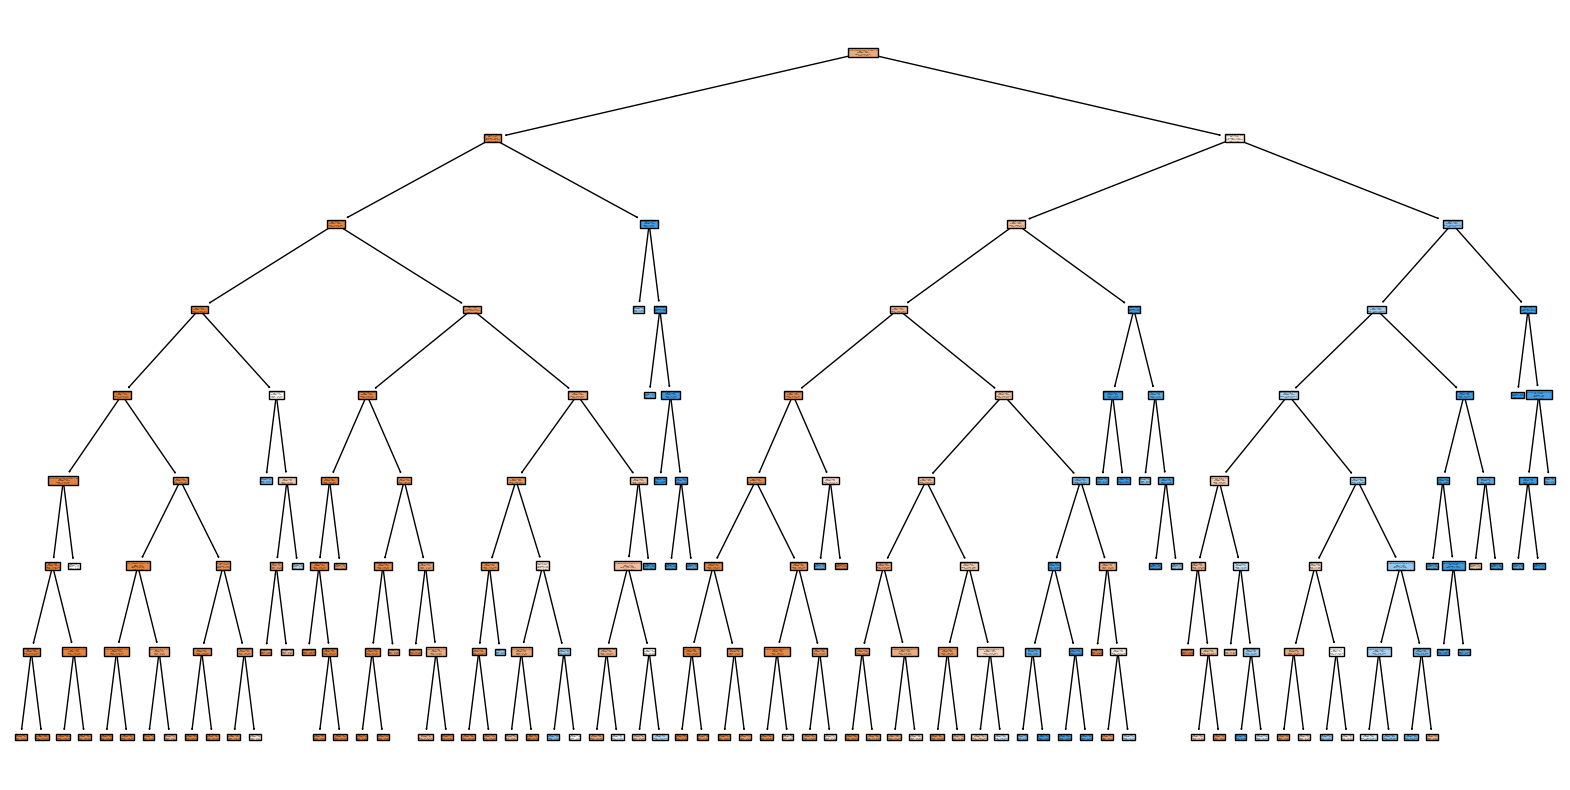

In [12]:
plt.figure(figsize=(20,10))

plot_tree(model,
          feature_names=X.columns,
          class_names=['<=50K','>50K'],
          filled=True)

plt.show()

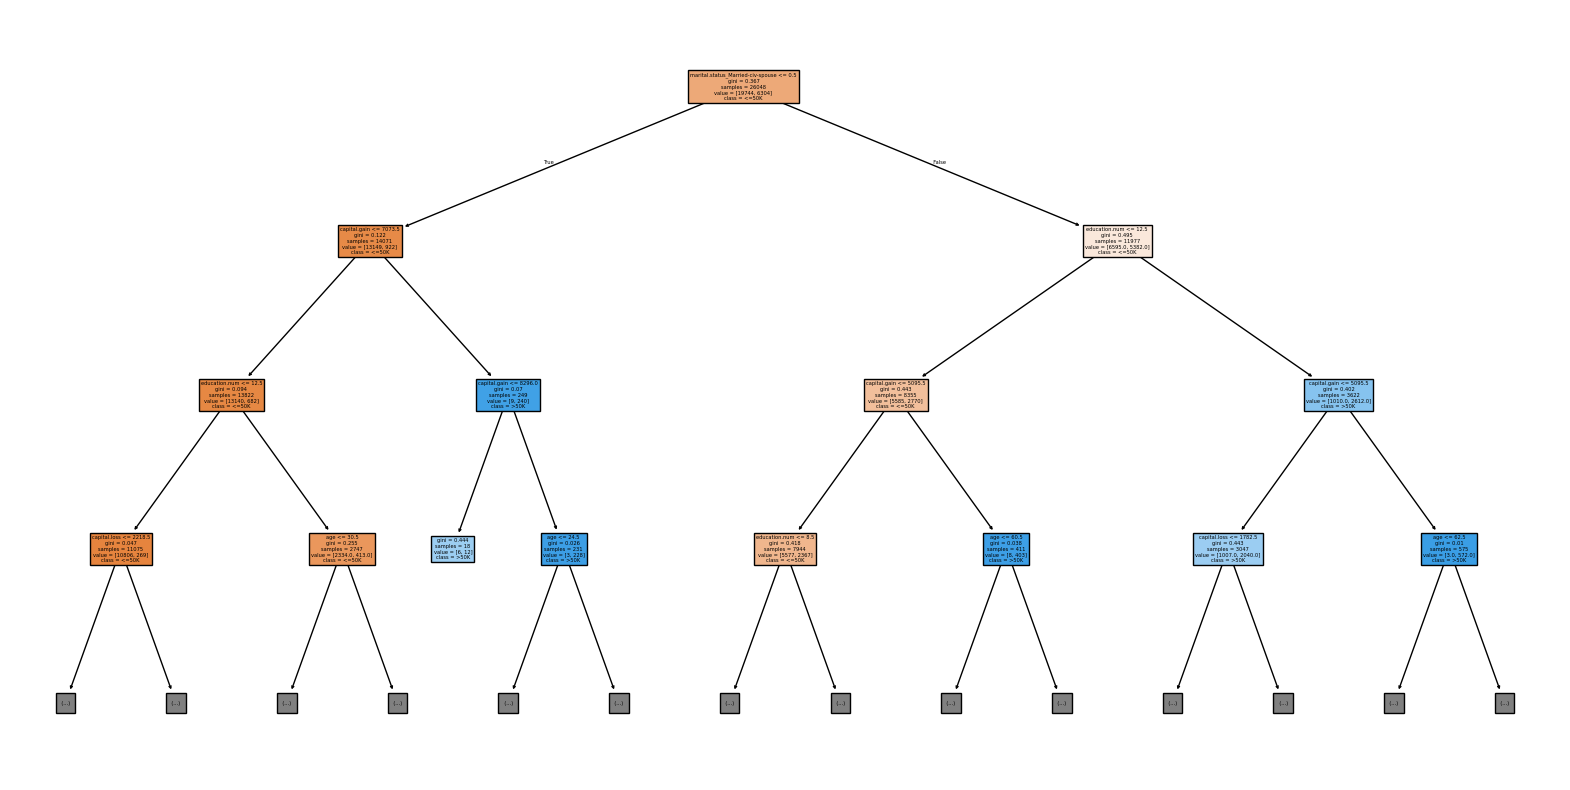

In [13]:
plt.figure(figsize=(20,10))

plot_tree(model,
          feature_names=X.columns,
          class_names=['<=50K','>50K'],
          filled=True,
          max_depth=3)

plt.show()